In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

os.makedirs("artifacts", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

In [2]:
df = pd.read_csv("S06-hw-dataset-02.csv")
print("✅ Используем датасет: S06-hw-dataset-02.csv")

X = df.drop(columns=['id', 'target'])
y = df['target']

✅ Используем датасет: S06-hw-dataset-02.csv


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [4]:
def compute_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_proba))
    }

In [5]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

In [6]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:, 1]

In [7]:
tree_params = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [5, 10, 20]  # ← контроль переобучения
}
tree = DecisionTreeClassifier(random_state=42)
tree_cv = GridSearchCV(tree, tree_params, cv=5, scoring='roc_auc', n_jobs=-1)
tree_cv.fit(X_train, y_train)  # только train!
best_tree = tree_cv.best_estimator_
y_pred_tree = best_tree.predict(X_test)
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]

In [8]:
rf_params = {'n_estimators': [100], 'max_depth': [5, 10, None], 'min_samples_leaf': [2, 5]}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_cv = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_cv.fit(X_train, y_train)
best_rf = rf_cv.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

In [9]:
boost_params = {'max_depth': [3, 5], 'learning_rate': [0.1], 'max_iter': [100]}
boost = HistGradientBoostingClassifier(random_state=42)
boost_cv = GridSearchCV(boost, boost_params, cv=5, scoring='roc_auc', n_jobs=-1)
boost_cv.fit(X_train, y_train)
best_boost = boost_cv.best_estimator_
y_pred_boost = best_boost.predict(X_test)
y_proba_boost = best_boost.predict_proba(X_test)[:, 1]

In [10]:
# Явные вызовы — никаких циклов с X_test!
metrics = {
    "Dummy": compute_metrics(y_test, y_pred_dummy, y_proba_dummy),
    "LogisticRegression": compute_metrics(y_test, y_pred_lr, y_proba_lr),
    "DecisionTree": compute_metrics(y_test, y_pred_tree, y_proba_tree),
    "RandomForest": compute_metrics(y_test, y_pred_rf, y_proba_rf),
    "HistGradientBoosting": compute_metrics(y_test, y_pred_boost, y_proba_boost),
}

best_model_name = max(metrics, key=lambda k: metrics[k]["roc_auc"])
model_map = {
    "Dummy": dummy,
    "LogisticRegression": lr_pipe,
    "DecisionTree": best_tree,
    "RandomForest": best_rf,
    "HistGradientBoosting": best_boost
}
best_model = model_map[best_model_name]
y_pred_best = best_model.predict(X_test)

<Figure size 500x400 with 0 Axes>

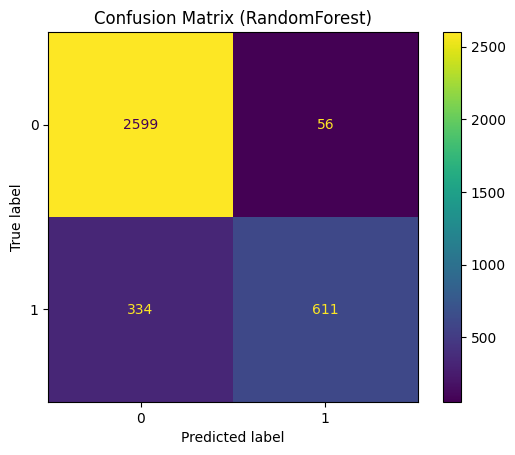

In [11]:
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=[0, 1])
plt.title(f"Confusion Matrix ({best_model_name})")
plt.savefig("artifacts/figures/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

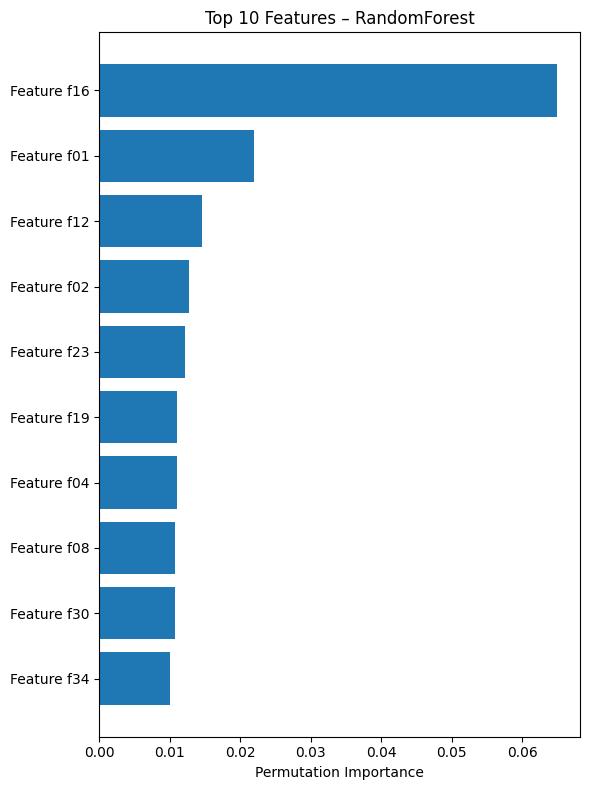

In [12]:
perm_imp = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

plt.figure(figsize=(6, 8))
indices = np.argsort(perm_imp.importances_mean)[::-1][:10]
top_features = X.columns[indices]
top_importances = perm_imp.importances_mean[indices]

plt.barh(range(len(top_features)), top_importances[::-1])
plt.yticks(range(len(top_features)), [f"Feature {f}" for f in top_features[::-1]])
plt.xlabel("Permutation Importance")
plt.title(f"Top 10 Features – {best_model_name}")
plt.tight_layout()
plt.savefig("artifacts/figures/permutation_importance.png", dpi=150)
plt.show()

In [13]:
# 1. metrics_test.json — ПЛОСКИЙ ОБЪЕКТ: модели → метрики
with open("artifacts/metrics_test.json", "w") as f:
    json.dump(metrics, f, indent=2)

# 2. search_summaries.json
search_summaries = {
    "DecisionTree": {"best_params": tree_cv.best_params_, "best_cv_score": float(tree_cv.best_score_)},
    "RandomForest": {"best_params": rf_cv.best_params_, "best_cv_score": float(rf_cv.best_score_)},
    "HistGradientBoosting": {"best_params": boost_cv.best_params_, "best_cv_score": float(boost_cv.best_score_)}
}
with open("artifacts/search_summaries.json", "w") as f:
    json.dump(search_summaries, f, indent=2)

# 3. best_model.joblib
joblib.dump(best_model, "artifacts/best_model.joblib")

# 4. best_model_meta.json
meta = {
    "best_model": best_model_name,
    "test_metrics": metrics[best_model_name]
}
with open("artifacts/best_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("✅ Все артефакты сохранены.")

✅ Все артефакты сохранены.
